# E45 · One family for every response curve: a Weibull transform in JAX for media models

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Conjura's open multi-brand e-commerce MMM dataset (Anderson 2024, CC BY 4.0): one UK apparel brand, 180 weeks (May 2020 - Oct 2023) of new customers and Google + Meta spend |
| **You will learn** | Why the choice of saturation curve (Hill, logistic, power, ...) is an assumption the data cannot undo · the **Weibull response family** $1 - e^{-c x^k}$, normalised at a reference spend, which contains power curves ($c \to 0$), concave saturation ($k \le 1$) and S-curves ($k > 1$) and moves smoothly between them · a **shape map** of the $(k, c)$ plane and the inflection point in closed form · writing it as a **custom JAX function** that survives $c = 0$, $x = 0$ and float32 (`expm1`, series switch, the double-`where` trick), with geometric adstock in `lax.scan` · unit tests: limits, finite-difference gradients, second derivatives from `jax.grad(jax.grad)` · **batched curve fitting with `vmap` + optax**: how closely the family reproduces Hill, logistic, Michaelis-Menten, tanh, log and power curves, and where it does not (the tails) · **translating a Hill prior** into the Weibull family · `pytensor.wrap_jax` + `pt.specify_shape` + `verify_grad` · a fake-data check where a concave-only model gets the marginal return wrong · the real brand: LOO against Hill and logistic models, the posterior on the shape map, marginal cost per customer from `vmap(grad)` · what the data can and cannot say about shape · Numba+JAX-op vs whole-model JAX timing |

A marketing-mix model (MMM) has to say what one more pound of spend buys, and that depends on
the **shape of the response curve**: does each extra pound buy a bit less (concave), a bit
more (convex), or does the curve start slowly, then climb, then flatten (S-shaped)? Every MMM
package chooses a family for you:

| library / tradition | default response curve | shapes it can take |
|---|---|---|
| Robyn (Meta), Meridian (Google), E33 here | Hill $x^n / (K^n + x^n)$ | concave or S |
| PyMC-Marketing | logistic saturation $(1 - e^{-\lambda x}) / (1 + e^{-\lambda x})$ | concave only |
| econometrics | power $x^k$, or $\log(1 + x)$ | concave or convex, never saturates |

A family is a prior with zero probability outside it. If the truth is S-shaped and the family
is concave-only, no amount of data can find the S. This notebook builds one smooth family that
contains all three behaviours, as a custom JAX function, and puts it in a Bayesian MMM so that
**the posterior, not the software default, chooses the shape**. We also find out where the data
cannot choose.

The plan: the family and its geometry (sections 1-2); a numerically safe JAX implementation
with tests (3); how closely it reproduces the standard curves, and how to carry a prior over
from one of them (4-5); the PyMC model and a fake-data check (6-7); a real brand (8);
performance (9).

In [1]:
import logging
import time
import warnings

import arviz as az
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import pandas as pd
import pymc as pm
import pytensor
import pytensor.tensor as pt
from IPython.display import display
from matplotlib.colors import ListedColormap
from matplotlib.ticker import FixedLocator, NullLocator

from pymc_challenges import data

jax.config.update("jax_enable_x64", True)
RANDOM_SEED = 45
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)  # several fits: no sampler banner per fit
# Expected and harmless: Numba runs the JAX node in object mode (section 9 measures the cost)
warnings.filterwarnings("ignore", message="Numba will use object mode")
warnings.filterwarnings("ignore", message="Skipping Check")  # JAX drops PyMC's parameter checks
BLUE, ORANGE, AQUA, GREY, PURPLE, RED = "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#8c5ac8", "#c8384e"
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}, PyTensor {pytensor.__version__}, "
      f"JAX {jax.__version__}, optax {optax.__version__}")

PyMC 6.3.2, ArviZ 1.3.0, PyTensor 3.3.2, JAX 0.11.2, optax 0.2.8


## 1 · Six standard curves, six different answers

Below are six textbook response curves. Each is scaled to pass through the same point: at the
reference spend $x = 1$ (think "an average week") the channel brings in one unit of response.
They agree there by construction, and they disagree about everything a budget decision needs:
the slope at $x = 1$ (the **marginal** return), what happens at half the spend, and what
happens at twice the spend.

[Text(0.5, 0, 'marginal return at the reference (1 = the average return)'),
 Text(0.5, 1.0, '...but marginal returns that differ by a factor of 4')]

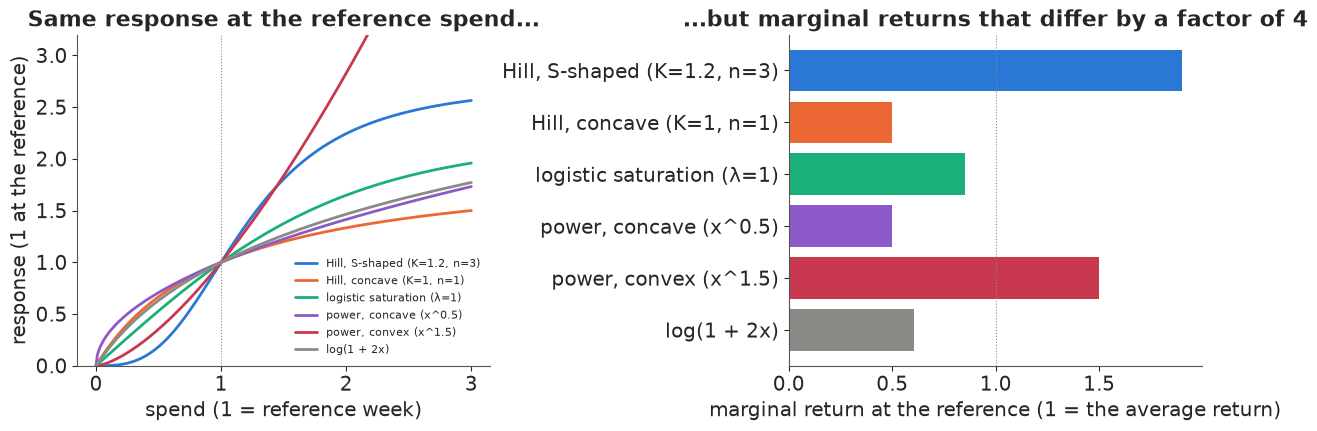

In [2]:
X_PLOT = np.linspace(0, 3, 301)


def hill_np(x, K, n):
    return x**n / (K**n + x**n)


def logistic_np(x, lam):
    return (1 - np.exp(-lam * x)) / (1 + np.exp(-lam * x))


standard = {
    "Hill, S-shaped (K=1.2, n=3)": lambda x: hill_np(x, 1.2, 3.0),
    "Hill, concave (K=1, n=1)": lambda x: hill_np(x, 1.0, 1.0),
    "logistic saturation (λ=1)": lambda x: logistic_np(x, 1.0),
    "power, concave (x^0.5)": lambda x: np.sqrt(x),
    "power, convex (x^1.5)": lambda x: x**1.5,
    "log(1 + 2x)": lambda x: np.log1p(2 * x),
}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
colors = [BLUE, ORANGE, AQUA, PURPLE, RED, GREY]
slopes = {}
for (name, f), col in zip(standard.items(), colors):
    y_ = f(X_PLOT) / f(1.0)
    axes[0].plot(X_PLOT, y_, color=col, lw=2, label=name)
    slopes[name] = (f(1.001) - f(0.999)) / 0.002 / f(1.0)
axes[0].axvline(1, color=GREY, lw=0.8, ls=":")
axes[0].set(xlabel="spend (1 = reference week)", ylabel="response (1 at the reference)",
            title="Same response at the reference spend...", ylim=(0, 3.2))
axes[0].legend(fontsize=8)
names = list(slopes)
axes[1].barh(names, [slopes[n] for n in names], color=colors)
axes[1].axvline(1, color=GREY, lw=0.8, ls=":")
axes[1].invert_yaxis()
axes[1].set(xlabel="marginal return at the reference (1 = the average return)",
            title="...but marginal returns that differ by a factor of 4")

The marginal return at the reference spend, relative to the average return, ranges from 0.5
(the concave Hill and square-root curves) to 1.9 (the S-curve, which is at its steepest near
the reference). "Spend 10%
more" is a good or a bad idea depending on which curve you assumed.

## 2 · The Weibull response family

The Weibull distribution's CDF, $1 - \exp(-(x/\lambda)^k)$, has long been used as a growth and
dose-response curve, and Robyn uses Weibull CDF/PDF shapes for **adstock**. Here we use it as
the **saturation** curve and write it in a form that keeps the power-law limit inside the family:

$$
f(x;\, k, c) \;=\; \frac{1 - e^{-c\,x^k}}{1 - e^{-c}}, \qquad k > 0,\; c \ge 0,
\qquad\text{so that } f(1) = 1 .
$$

The response of a channel is $\beta\, f(x)$, where $x$ is (adstocked) spend divided by its
average and $\beta$ is the response in an average week. The normalisation at $x = 1$ is what
makes $\beta$ interpretable and separates "how big" ($\beta$) from "what shape" ($k$, $c$).

**Three behaviours, one family.**

- **Power curves as $c \to 0$.** Since $1 - e^{-u} \approx u$ for small $u$, the ratio tends to
  $c x^k / c = x^k$: the econometrician's power curve, concave for $k < 1$, linear at $k = 1$,
  convex for $k > 1$, never saturating. The limit is smooth: $c$ is a continuous "how much
  saturation" knob that is exactly zero for a power curve.
- **Concave saturation for $k \le 1$, $c > 0$.** At $k = 1$ it is the exponential saturation
  curve $1 - e^{-cx}$ (the numerator of the logistic saturation curve); for $k < 1$ it rises
  even faster at first.
- **S-curves for $k > 1$, $c > 0$.** The second derivative has the sign of
  $(k - 1) - c k x^k$, so there is exactly one inflection point

$$ x^\ast = \left(\frac{k - 1}{c\,k}\right)^{1/k}. $$

Below $x^\ast$ each extra pound buys more than the last; above it, less. Whether a fitted curve
"is" S-shaped therefore depends on whether $x^\ast$ lies **inside the range of spend you have
seen**. If $x^\ast$ is far to the right, the curve is convex over the whole data; if it is near
zero, the curve is concave over the whole data. The **shape map** below colours the $(k, c)$
plane by what the curve looks like on $0 \le x \le 2.5$, the range this notebook's brand
actually spends in.

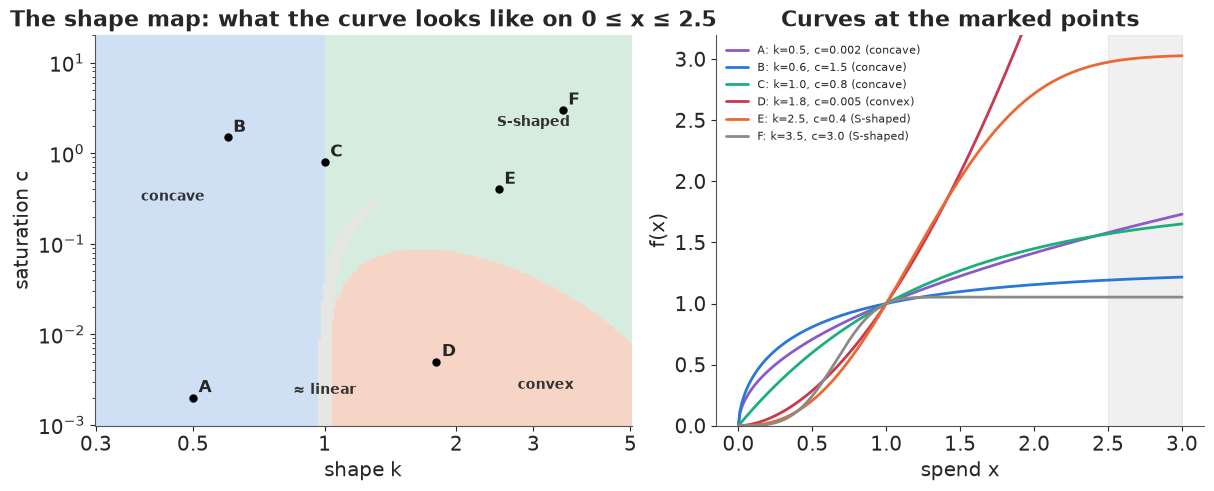

In [3]:
X_RANGE = 2.5  # the spend range we care about, in units of an average week


def weibull_np(x, k, c):
    """Reference NumPy version, for plotting only (section 3 writes the careful one)."""
    c = np.maximum(c, 1e-12)
    return -np.expm1(-c * x**k) / -np.expm1(-c)


def inflection(k, c):
    """x* = ((k - 1) / (c k))^(1/k) for k > 1; inf where there is none."""
    with np.errstate(invalid="ignore", divide="ignore", over="ignore"):
        return np.where(k > 1, ((k - 1) / np.maximum(c * k, 1e-300)) ** (1 / k), np.inf)


def shape_class(k, c, x_max=X_RANGE, tol=0.03):
    """0 concave, 1 ~linear, 2 convex, 3 S-shaped (inflection inside (0, x_max))."""
    k, c = np.broadcast_arrays(np.asarray(k, float), np.asarray(c, float))
    xs = np.linspace(0, x_max, 101)
    curves = weibull_np(xs[:, None], k.ravel()[None], c.ravel()[None])  # (x, points)
    near_linear = (np.abs(curves - xs[:, None]).max(0) < tol * x_max).reshape(k.shape)
    x_star = inflection(k, c)
    out = np.where(k <= 1, 0, np.where(x_star < x_max, 3, 2))
    return np.where(near_linear, 1, out)


SHAPE_NAMES = ["concave", "≈ linear", "convex", "S-shaped"]
SHAPE_CMAP = ListedColormap(["#cfe0f5", "#e6e6e3", "#f7d5c6", "#d5ecdf"])
kg = np.exp(np.linspace(np.log(0.3), np.log(5), 240))
cg = np.exp(np.linspace(np.log(1e-3), np.log(20), 240))
KG, CG = np.meshgrid(kg, cg, indexing="xy")
SHAPE_GRID = shape_class(KG, CG)


def draw_shape_map(ax, labels=True):
    ax.pcolormesh(kg, cg, SHAPE_GRID, cmap=SHAPE_CMAP, vmin=-0.5, vmax=3.5, shading="auto",
                  rasterized=True)
    ax.set(xscale="log", yscale="log", xlabel="shape k", ylabel="saturation c")
    ax.xaxis.set_major_locator(FixedLocator([0.3, 0.5, 1, 2, 3, 5]))
    ax.xaxis.set_minor_locator(NullLocator())
    ax.set_xticklabels(["0.3", "0.5", "1", "2", "3", "5"])
    if labels:
        for (kx, cy), name in zip([(0.45, 0.3), (1.0, 0.0022), (3.2, 0.0025), (3.0, 2.0)], SHAPE_NAMES):
            ax.text(kx, cy, name, ha="center", fontsize=10, color="#333333", weight="bold")


examples = {"A": (0.5, 0.002), "B": (0.6, 1.5), "C": (1.0, 0.8), "D": (1.8, 0.005),
            "E": (2.5, 0.4), "F": (3.5, 3.0)}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), gridspec_kw={"width_ratios": [1.1, 1]})
draw_shape_map(axes[0])
for lab, (k_, c_) in examples.items():
    axes[0].plot(k_, c_, "o", color="k", ms=5)
    axes[0].annotate(lab, (k_, c_), xytext=(4, 4), textcoords="offset points", weight="bold")
axes[0].set_title(f"The shape map: what the curve looks like on 0 ≤ x ≤ {X_RANGE}")
for (lab, (k_, c_)), col in zip(examples.items(), [PURPLE, BLUE, AQUA, RED, ORANGE, GREY]):
    cls = SHAPE_NAMES[int(shape_class(k_, c_))]
    axes[1].plot(X_PLOT, weibull_np(X_PLOT, k_, c_), color=col, lw=2,
                 label=f"{lab}: k={k_}, c={c_} ({cls})")
axes[1].axvspan(X_RANGE, 3, color=GREY, alpha=0.12)
axes[1].set(xlabel="spend x", ylabel="f(x)", ylim=(0, 3.2), title="Curves at the marked points")
axes[1].legend(fontsize=8)

Points A and D are power curves (tiny $c$); B and C saturate; E and F are S-curves whose
inflection points (about 1.2 and 0.7) lie inside the data range. The boundaries of the map
are where a decision changes character: crossing from "convex" to "S-shaped" means an
inflection point has entered the data. Nothing about the family is discontinuous there, which
is exactly what NUTS needs.

## 3 · A custom JAX function that does not break

The formula is one line. Written naively, it breaks in three places that a sampler **will**
visit:

In [4]:
def weibull_naive(x, k, c):
    return (1 - jnp.exp(-c * x**k)) / (1 - jnp.exp(-c))


xs = jnp.array([0.5, 1.0, 2.0])
print("1. c = 0 exactly (a pure power curve):", weibull_naive(xs, 1.5, 0.0))
for c_small in (1e-6, 1e-10, 1e-13):
    rel = np.max(np.abs(weibull_naive(xs, 1.5, c_small) / xs**1.5 - 1))
    print(f"2. c = {c_small:.0e}: relative error vs the exact limit x^k = {rel:.1e}")
with jax.enable_x64(False):
    x32 = jnp.array([0.5, 1.0, 2.0], dtype=jnp.float32)
    for c_small in (1e-4, 1e-6):
        rel32 = np.max(np.abs(weibull_naive(x32, 1.5, jnp.float32(c_small)) / x32**1.5 - 1))
        print(f"   float32, c = {c_small:.0e}: relative error {rel32:.1e}")
pow_via_log = lambda x, k: jnp.where(x > 0, jnp.exp(k * jnp.log(x)), 0.0)  # noqa: E731
print("3. d/dk of x^k at x = 0, written as exp(k log x) under a where:",
      jax.grad(pow_via_log, argnums=1)(0.0, 1.5))
print("   d/dx of x^0.5 at x = 0 with jnp.power:", jax.grad(lambda x: x**0.5)(0.0))

1. c = 0 exactly (a pure power curve): [nan nan nan]
2. c = 1e-06: relative error vs the exact limit x^k = 9.1e-07
2. c = 1e-10: relative error vs the exact limit x^k = 1.2e-06
2. c = 1e-13: relative error vs the exact limit x^k = 1.7e-03
   float32, c = 1e-04: relative error 4.4e-04
   float32, c = 1e-06: relative error 2.3e-02
3. d/dk of x^k at x = 0, written as exp(k log x) under a where: nan
   d/dx of x^0.5 at x = 0 with jnp.power: inf


1. **$c = 0$ is $0/0$.** It is a legitimate parameter value (the power curve), and a prior on
   $c$ that allows it will sample close to it.
2. **Small $c$ cancels catastrophically.** $1 - e^{-u}$ for tiny $u$ subtracts two nearly equal
   numbers, and the relative error grows like (machine precision) / $c$. In float64 it is
   $10^{-6}$ at $c = 10^{-10}$ and $10^{-3}$ at $c = 10^{-13}$; in float32 (JAX's default, and
   what a GPU prefers) the same happens about eight orders of magnitude sooner: a 2% error
   at $c = 10^{-6}$.
3. **Zero spend.** Weeks with no spend give $x = 0$. The derivative of $x^k$ with respect to
   $x$ is infinite there for $k < 1$, and the common idiom `where(x > 0, exp(k log x), 0)` gives
   a **NaN gradient** even though its value is fine: `where` differentiates *both* branches and
   multiplies the untaken one by zero, and $0 \times (-\infty) = $ NaN. (PyTensor's `switch`
   does the same; see the gotcha from E08.)

The fixes are standard:

- write $\frac{1 - e^{-cz}}{c} = z \cdot \phi(cz)$ with $\phi(u) = (1 - e^{-u})/u$, evaluated
  with `expm1` and replaced by its Taylor series $1 - u/2 + u^2/6 - u^3/24$ below $u = 10^{-4}$
  (where the truncation error, about $u^4/120$, is below float64 rounding). Then
  $f(x) = x^k\,\phi(c x^k) / \phi(c)$, and $c = 0$ is an ordinary point.
- the **double-`where` trick**: first replace the bad input by a harmless one, *then* compute,
  then select. The untaken branch is now finite, so its zero weight gives a zero gradient.

In [5]:
SERIES_BELOW = 1e-4


def phi(u):
    """(1 - exp(-u)) / u for u >= 0, with phi(0) = 1; stable at all u, including under grad."""
    small = u < SERIES_BELOW
    u_safe = jnp.where(small, 1.0, u)  # double-where: the untaken branch never sees u = 0
    return jnp.where(small, 1 - u / 2 + u**2 / 6 - u**3 / 24, -jnp.expm1(-u_safe) / u_safe)


def safe_pow(x, k):
    """x**k for x >= 0 with finite gradients in x and k at x = 0 (value and gradients 0 there)."""
    pos = x > 0
    x_safe = jnp.where(pos, x, 1.0)
    return jnp.where(pos, jnp.exp(k * jnp.log(x_safe)), 0.0)


def weibull(x, k, c):
    """Weibull response f(x) = (1 - exp(-c x^k)) / (1 - exp(-c)), exact at c = 0 (f = x^k)."""
    z = safe_pow(x, k)
    return z * phi(c * z) / phi(c)


def geometric_adstock(x, theta):
    """x (week, channel), theta (channel,) -> a_t = theta a_{t-1} + (1 - theta) x_t.

    The (1 - theta) weight keeps the long-run level of a constant spend unchanged, so x = 1 still
    means "an average week". The recursion starts from the mean of the first 8 weeks."""
    def step(a, x_t):
        a = theta * a + (1 - theta) * x_t
        return a, a

    _, out = jax.lax.scan(step, x[:8].mean(axis=0), x)
    return out


def media_transform(x, theta, k, c):
    """Spend (week, channel) -> adstocked, saturated response curves (week, channel)."""
    return weibull(geometric_adstock(x, theta), k, c)


weibull_jit = jax.jit(weibull)
print("c = 0 now gives x^k:          ", weibull_jit(xs, 1.5, 0.0), "vs", xs**1.5)
print("d/dk at x = 0:                ", jax.grad(weibull, argnums=1)(0.0, 1.5, 0.5))
print("d/dx at x = 0, k = 0.5:       ", jax.grad(weibull, argnums=0)(0.0, 0.5, 0.5))

c = 0 now gives x^k:           [0.35355339 1.         2.82842712] vs [0.35355339 1.         2.82842712]


d/dk at x = 0:                 0.0
d/dx at x = 0, k = 0.5:        0.0


### Tests

A likelihood component is code, so it gets unit tests. Four properties:

1. the $c \to 0$ limit is the power curve, and the function is continuous across the series
   switch at $c x^k = 10^{-4}$;
2. gradients in $k$ and $c$ agree with central finite differences, on both sides of the switch;
3. float32 agrees with float64 to float32 precision (so it would run on a GPU);
4. the second derivative from `jax.grad(jax.grad(...))` changes sign exactly at the closed-form
   inflection point $x^\ast$.

In [6]:
# 1. limit and continuity
for c_ in (1e-2, 1e-4, 1e-8, 0.0):
    err = float(jnp.max(jnp.abs(weibull(xs, 1.5, c_) - xs**1.5)))
    print(f"c = {c_:.0e}: max |f - x^k| = {err:.1e}")
u_edge = SERIES_BELOW
jump = abs(float(phi(u_edge * (1 - 1e-12)) - phi(u_edge * (1 + 1e-12))))
print(f"jump in phi across the series switch: {jump:.1e}")

# 2. gradients vs finite differences, both sides of the switch
test_points = [(0.7, 1.3, 0.0), (0.7, 1.3, 0.99e-4), (0.7, 1.3, 1.01e-4), (1.8, 0.6, 2.0),
               (2.4, 3.5, 5.0), (0.0, 0.8, 1.0)]
worst = 0.0
for x_, k_, c_ in test_points:
    g = jax.grad(weibull, argnums=(1, 2))(x_, k_, c_)
    h = 1e-6
    fd_k = (weibull(x_, k_ + h, c_) - weibull(x_, k_ - h, c_)) / (2 * h)
    fd_c = (weibull(x_, k_, c_ + h) - weibull(x_, k_, max(c_ - h, 0.0))) / (h + min(h, c_))
    worst = max(worst, abs(float(g[0] - fd_k)), abs(float(g[1] - fd_c)))
print(f"worst |autodiff - finite difference| over {len(test_points)} points: {worst:.1e}")

# 3. float32 vs float64
xg64 = jnp.linspace(0, 3, 50)
with jax.enable_x64(False):
    f32 = np.asarray(weibull(jnp.asarray(xg64, jnp.float32), jnp.float32(2.2), jnp.float32(3e-5)))
f64 = np.asarray(weibull(xg64, 2.2, 3e-5))
print(f"float32 vs float64, c = 3e-5: max relative difference {np.max(np.abs(f32[1:] / f64[1:] - 1)):.1e}")

# 4. inflection point
k_, c_ = 2.5, 0.4
d2 = jax.vmap(jax.grad(jax.grad(weibull)), in_axes=(0, None, None))
xfine = jnp.linspace(0.05, 3, 20001)
x_sign_change = float(xfine[jnp.argmax(d2(xfine, k_, c_) < 0)])
print(f"inflection: second derivative changes sign at x = {x_sign_change:.4f}, "
      f"closed form x* = {((k_ - 1) / (c_ * k_)) ** (1 / k_):.4f}")

c = 1e-02: max |f - x^k| = 2.6e-02
c = 1e-04: max |f - x^k| = 2.6e-04
c = 1e-08: max |f - x^k| = 2.6e-08
c = 0e+00: max |f - x^k| = 4.4e-16
jump in phi across the series switch: 1.1e-16


worst |autodiff - finite difference| over 6 points: 4.9e-09


float32 vs float64, c = 3e-5: max relative difference 2.9e-07


inflection: second derivative changes sign at x = 1.1762, closed form x* = 1.1761


All four pass: the error against $x^k$ falls in proportion to $c$ and is exactly zero at
$c = 0$, the switch is seamless, gradients agree with finite differences to about $10^{-9}$
(the finite-difference error itself), float32 is good to about $10^{-7}$, and autodiff
locates the inflection point where the algebra says it is.

## 4 · How well does one family imitate the others?

If the Weibull family is to stand in for the standard transforms, it has to reproduce them
closely **over the range of the data**. That is a curve-fitting question with thousands of
independent fits, which is what `jax.vmap` is for: write one least-squares fit (Adam from
optax, 3,000 steps in a `lax.scan`, three starting points), then map it over a whole grid of
target curves. The free parameters are $(\log\beta, \log k, \log c)$; the error is the largest
gap between the curves on $0 \le x \le 3$, as a fraction of the target's maximum.

In [7]:
X_FIT = jnp.linspace(0, 3, 121)
STARTS = jnp.array([[0.0, 0.0, -1.0], [0.0, 0.7, 0.0], [0.0, -0.5, 1.0]])
adam = optax.adam(0.05)


def weibull_curve(p, x=X_FIT):
    return jnp.exp(p[0]) * weibull(x, jnp.exp(p[1]), jnp.exp(p[2]))


def fit_from(target, p0, steps=3000):
    loss = lambda p: jnp.mean((weibull_curve(p) - target) ** 2)  # noqa: E731

    def step(carry, _):
        p, state = carry
        updates, state = adam.update(jax.grad(loss)(p), state, p)
        return (optax.apply_updates(p, updates), state), None

    (p, _), _ = jax.lax.scan(step, (p0, adam.init(p0)), None, length=steps)
    return p, jnp.max(jnp.abs(weibull_curve(p) - target)) / jnp.max(target)


def fit_best(target):
    ps, errs = jax.vmap(fit_from, in_axes=(None, 0))(target, STARTS)
    best = jnp.argmin(errs)
    return ps[best], errs[best]


fit_many = jax.jit(jax.vmap(fit_best))  # (n_curves, 121) -> params (n_curves, 3), errors (n_curves,)

K_GRID = np.linspace(0.3, 3.0, 28)
N_GRID = np.linspace(0.5, 4.0, 29)
KK, NN = np.meshgrid(K_GRID, N_GRID, indexing="ij")
hill_targets = jnp.asarray(hill_np(np.asarray(X_FIT)[None], KK.ravel()[:, None], NN.ravel()[:, None]))
t0 = time.perf_counter()
hill_params, hill_err = jax.block_until_ready(fit_many(hill_targets))
print(f"{len(hill_targets)} Hill curves x 3 starts x 3000 Adam steps: {time.perf_counter() - t0:.1f} s")
HILL_ERR = np.asarray(hill_err).reshape(KK.shape)
print(f"max error over the Hill grid: median {100 * np.median(HILL_ERR):.1f}%, "
      f"90th percentile {100 * np.quantile(HILL_ERR, 0.9):.1f}%, worst {100 * HILL_ERR.max():.1f}%")

812 Hill curves x 3 starts x 3000 Adam steps: 4.1 s
max error over the Hill grid: median 1.2%, 90th percentile 3.6%, worst 4.7%


In [8]:
gallery = {
    "logistic saturation λ=1": logistic_np(X_FIT, 1.0),
    "logistic saturation λ=3": logistic_np(X_FIT, 3.0),
    "Michaelis-Menten x/(0.8+x)": X_FIT / (0.8 + X_FIT),
    "tanh(x/1.5)": np.tanh(X_FIT / 1.5),
    "log(1 + 2x)": np.log1p(2 * X_FIT),
    "power x^0.5": np.sqrt(X_FIT),
    "power x^1.6": X_FIT**1.6,
    "shifted sigmoid": 1 / (1 + np.exp(-3 * (X_FIT - 1.5))) - 1 / (1 + np.exp(4.5)),
}
gal_params, gal_err = fit_many(jnp.asarray(np.stack([np.asarray(v) for v in gallery.values()])))
gal_params, gal_err = np.asarray(gal_params), np.asarray(gal_err)
display(pd.DataFrame({"k": np.exp(gal_params[:, 1]), "c": np.exp(gal_params[:, 2]),
                      "max error (% of max)": 100 * gal_err}, index=list(gallery)).round(3))

,k,c,max error (% of max)
logistic saturation λ=1,1.143,0.594,0.742
logistic saturation λ=3,1.191,2.323,1.147
Michaelis-Menten x/(0.8+x),0.839,1.080,1.449
tanh(x/1.5),1.168,0.863,0.933
log(1 + 2x),0.829,0.541,1.060
power x^0.5,0.513,0.047,0.259
power x^1.6,1.643,0.017,0.387
shifted sigmoid,3.140,0.196,1.530


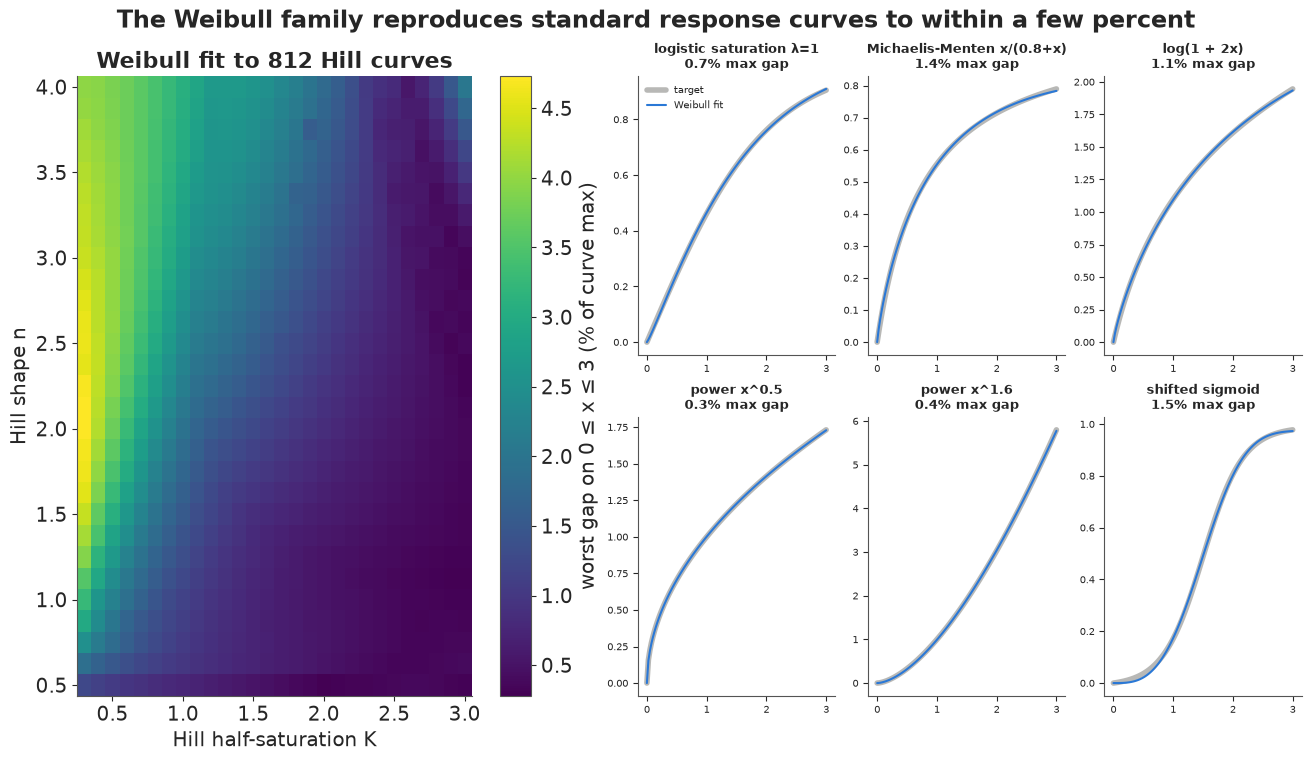

In [9]:
fig = plt.figure(figsize=(13, 7.5), layout="constrained")
gs = fig.add_gridspec(2, 5, height_ratios=[1, 1])
ax_h = fig.add_subplot(gs[:, :2])
im = ax_h.pcolormesh(K_GRID, N_GRID, 100 * HILL_ERR.T, cmap="viridis", shading="auto")
fig.colorbar(im, ax=ax_h, label="worst gap on 0 ≤ x ≤ 3 (% of curve max)")
ax_h.set(xlabel="Hill half-saturation K", ylabel="Hill shape n",
         title="Weibull fit to 812 Hill curves")
SHOW = ["logistic saturation λ=1", "Michaelis-Menten x/(0.8+x)", "log(1 + 2x)",
        "power x^0.5", "power x^1.6", "shifted sigmoid"]
gal_names = list(gallery)
gal_axes = [fig.add_subplot(gs[r, 2 + col]) for r in range(2) for col in range(3)]
for ax, name in zip(gal_axes, SHOW):
    i = gal_names.index(name)
    ax.plot(X_FIT, gallery[name], color=GREY, lw=4, alpha=0.6, label="target")
    ax.plot(X_FIT, weibull_curve(jnp.asarray(gal_params[i])), color=BLUE, lw=1.5, label="Weibull fit")
    ax.set_title(f"{name}\n{100 * gal_err[i]:.1f}% max gap", fontsize=9)
    ax.tick_params(labelsize=7)
gal_axes[0].legend(fontsize=7)
fig.suptitle("The Weibull family reproduces standard response curves to within a few percent");

Over the fitted range the family is a very good imitator. Across 812 Hill curves the worst gap
is a few percent of the curve's height and usually about 1%; the other standard shapes are
reproduced to within about 1.5%. Weekly MMM data are far noisier than that (section 8 finds weekly
new customers scattering by about 16% around the model mean), so **inside the data** no experiment
could tell a Hill curve from its Weibull twin. The fits are hardest for Hill curves with large
$n$ and large $K$: steep S-curves that are still rising at the edge of the range.

**Where the imitation fails: outside the range.** Hill curves approach their ceiling like a
power of $1/x$; Weibull curves approach theirs exponentially fast. Fitted on $[0, 3]$, the two
agree there and part company beyond it:

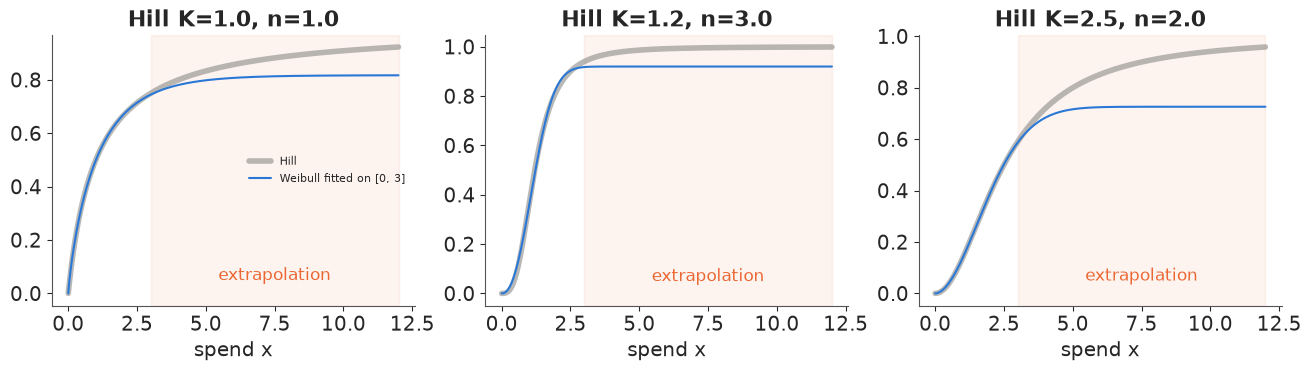

In [10]:
X_FAR = jnp.linspace(0, 12, 400)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=False)
for ax, (K_, n_) in zip(axes, [(1.0, 1.0), (1.2, 3.0), (2.5, 2.0)]):
    target = hill_np(np.asarray(X_FIT), K_, n_)
    p, e = fit_best(jnp.asarray(target))
    ax.plot(X_FAR, hill_np(np.asarray(X_FAR), K_, n_), color=GREY, lw=4, alpha=0.6, label="Hill")
    ax.plot(X_FAR, weibull_curve(p, X_FAR), color=BLUE, lw=1.5, label="Weibull fitted on [0, 3]")
    ax.axvspan(3, 12, color=ORANGE, alpha=0.08)
    ax.text(7.5, 0.05, "extrapolation", color=ORANGE, ha="center")
    ax.set(title=f"Hill K={K_}, n={n_}", xlabel="spend x")
axes[0].legend(fontsize=8)

This is not a defect of either family: it shows that **the shape of a response curve beyond
the data is set by the family, not by the data**. Every MMM that recommends quadrupling a
budget is reporting its functional form. We come back to this in section 8.

## 5 · Carrying a Hill prior into the Weibull family

Teams often have priors written for a particular curve: Meridian and Robyn users think in
Hill $(K, n)$, and E33 put a prior on the half-saturation point. The same batched fitter
**translates** such a prior: draw curves from the Hill prior, fit each with the Weibull family,
and look at the cloud of $(k, c)$ values. Here the prior is $K \sim \text{LogNormal}(\log 1.5,
0.5)$, $n \sim \text{LogNormal}(\log 1.5, 0.4)$, with curves normalised at $x = 1$ and fitted on
the data range $[0, 2.5]$.

In [11]:
N_PRIOR = 1000
K_prior = np.exp(rng.normal(np.log(1.5), 0.5, N_PRIOR))
n_prior = np.exp(rng.normal(np.log(1.5), 0.4, N_PRIOR))
X_DATA_RANGE = jnp.linspace(0, X_RANGE, 101)
prior_targets = hill_np(np.asarray(X_DATA_RANGE)[None], K_prior[:, None], n_prior[:, None])
prior_targets /= hill_np(1.0, K_prior, n_prior)[:, None]


def fit_best_range(target):
    """As fit_best, on the data range [0, 2.5]."""
    def fit_from_r(p0):
        loss = lambda p: jnp.mean((weibull_curve(p, X_DATA_RANGE) - target) ** 2)  # noqa: E731

        def step(carry, _):
            p, state = carry
            updates, state = adam.update(jax.grad(loss)(p), state, p)
            return (optax.apply_updates(p, updates), state), None

        (p, _), _ = jax.lax.scan(step, (p0, adam.init(p0)), None, length=3000)
        return p, jnp.max(jnp.abs(weibull_curve(p, X_DATA_RANGE) - target)) / jnp.max(target)

    ps, errs = jax.vmap(fit_from_r)(STARTS)
    return ps[jnp.argmin(errs)], jnp.min(errs)


prior_params, prior_err = jax.jit(jax.vmap(fit_best_range))(jnp.asarray(prior_targets))
log_kc = np.asarray(prior_params)[:, 1:]  # (log k, log c)
print(f"translation error: median {100 * np.median(prior_err):.1f}%, worst {100 * np.max(prior_err):.1f}%")
mean_kc, cov_kc = log_kc.mean(0), np.cov(log_kc.T)
print("translated prior: (log k, log c) ~ MvNormal(mean =", mean_kc.round(2), ", sd =",
      np.sqrt(np.diag(cov_kc)).round(2), ", corr =", round(cov_kc[0, 1] / np.sqrt(np.prod(np.diag(cov_kc))), 2), ")")

translation error: median 0.7%, worst 4.1%
translated prior: (log k, log c) ~ MvNormal(mean = [ 0.28 -0.58] , sd = [0.38 0.75] , corr = -0.58 )


shape classes, Hill prior draws: {'concave': np.float64(0.225), '≈ linear': np.float64(0.003), 'convex': np.float64(0.015), 'S-shaped': np.float64(0.757)}


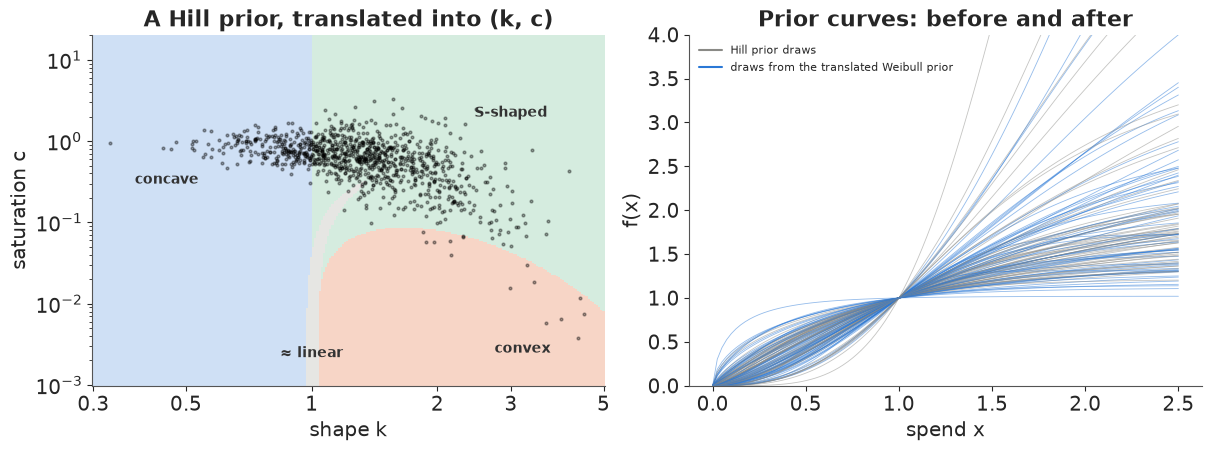

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
draw_shape_map(axes[0])
axes[0].scatter(np.exp(log_kc[:, 0]), np.exp(log_kc[:, 1]), s=4, color="k", alpha=0.35)
axes[0].set_title("A Hill prior, translated into (k, c)")
kc_draws = np.exp(rng.multivariate_normal(mean_kc, cov_kc, 200))
for i in range(60):
    axes[1].plot(X_DATA_RANGE, prior_targets[i], color=GREY, lw=0.6, alpha=0.5)
    axes[1].plot(X_DATA_RANGE, weibull_np(np.asarray(X_DATA_RANGE), *kc_draws[i]), color=BLUE,
                 lw=0.6, alpha=0.5)
axes[1].plot([], [], color=GREY, label="Hill prior draws")
axes[1].plot([], [], color=BLUE, label="draws from the translated Weibull prior")
axes[1].set(xlabel="spend x", ylabel="f(x)", ylim=(0, 4), title="Prior curves: before and after")
axes[1].legend(fontsize=8)
print("shape classes, Hill prior draws:", dict(zip(SHAPE_NAMES, np.bincount(
    shape_class(np.exp(log_kc[:, 0]), np.exp(log_kc[:, 1])), minlength=4) / N_PRIOR)))

The Hill prior becomes a tilted cloud, mostly in the S-shaped region with a tail into the
concave one, and $\log k$ and $\log c$ are negatively correlated: a steeper rise (larger $k$)
goes with a later onset of saturation (smaller $c$). A bivariate normal on $(\log k, \log c)$
is a rough summary of it: its prior curves (blue) cover the Hill ones (grey) but are more
spread out, with a few steep convex curves the Hill prior never makes. The count of shape
classes is the useful summary: this Hill prior, which looks neutral in $(K, n)$, says the
curve is **S-shaped over the data range three times out of four**. That is worth knowing before
fitting anything.

In the rest of the notebook we use a prior that is neutral about shape instead:
$k \sim \text{LogNormal}(0, 0.5)$ (so concave and convex are equally likely a priori) and
$c \sim \text{HalfNormal}(1.5)$ (anything from almost-power to strong saturation).

## 6 · Into PyMC with `pytensor.wrap_jax`

`wrap_jax` turns the JAX function into a PyTensor `Op` with a JAX gradient (E09 shows what it
builds). Two practical points: the spend matrix is data, so we close over it and wrap a
function of the parameters only; and variables declared with `dims=` have symbolic shapes,
so we pin them with `pt.specify_shape` at the boundary.

### The data

The brand is a UK apparel retailer in the Conjura dataset (series `6b89cf94`, also used in
E35), with Google (search, shopping, PMax) and Meta (Facebook, Instagram) spend. The two
channels' weekly spend is only weakly correlated, which is what lets a model tell them apart.

In [13]:
data.describe("conjura_mmm")
raw = data.load("conjura_mmm")
SERIES = "6b89cf94d2e23372be3846ed656b5e47"
d = raw[raw["MMM_TIMESERIES_ID"] == SERIES].copy()
d["date"] = pd.to_datetime(d["DATE_DAY"])
spend_cols = [c for c in d.columns if c.endswith("_SPEND")]
d[spend_cols] = d[spend_cols].fillna(0)  # NaN spend = channel not used (dataset documentation)
d["google"] = d[[c for c in spend_cols if c.startswith("GOOGLE")]].sum(axis=1)
d["meta"] = d[[c for c in spend_cols if c.startswith("META")]].sum(axis=1)
print("TikTok spend in this series:", d["TIKTOK_SPEND"].sum())
daily = d.set_index("date").sort_index()
weekly_all = daily[["FIRST_PURCHASES", "google", "meta"]].resample("W-SUN").sum()
weekly_all = weekly_all[daily["FIRST_PURCHASES"].resample("W-SUN").count() == 7]  # full weeks only
zero_meta = weekly_all.index[weekly_all["meta"] == 0]
feed_end = weekly_all.index[weekly_all["meta"] < 0.1 * weekly_all["meta"].median()].min()
print(f"{len(weekly_all)} full weeks, {weekly_all.index.min().date()} -> {weekly_all.index.max().date()}")
print("weeks with zero Meta spend:", len(zero_meta), "from", zero_meta.min().date(), "to", zero_meta.max().date())
print(weekly_all.loc[feed_end - pd.Timedelta(weeks=2):feed_end + pd.Timedelta(weeks=1)].round(0))

conjura_mmm: 132,759 brand x territory x day rows (143 anonymised series from 93 e-commerce brands, 2019-2024): first-time and all purchases (orders, units, original price, discount), and spend / clicks / impressions for Google (search, shopping, PMax, display, video), Meta (Facebook, Instagram, other) and TikTok, plus organic/direct/email/referral clicks. Missing spend means the brand did not use that channel.
  source: Anderson, A. (2024), Multi-Region Marketing Mix Modelling (MMM) Dataset for Several eCommerce Brands, Conjura, figshare, doi:10.6084/m9.figshare.25314841 (CC BY 4.0).
  url:    https://ndownloader.figshare.com/files/46779652


TikTok spend in this series: 0.0
197 full weeks, 2020-05-03 -> 2024-02-04
weeks with zero Meta spend: 16 from 2023-10-22 to 2024-02-04
            FIRST_PURCHASES   google     meta
date                                         
2023-10-01              714   8677.0  38860.0
2023-10-08              736  10176.0  36129.0
2023-10-15              778  11749.0    549.0
2023-10-22              621  10258.0      0.0


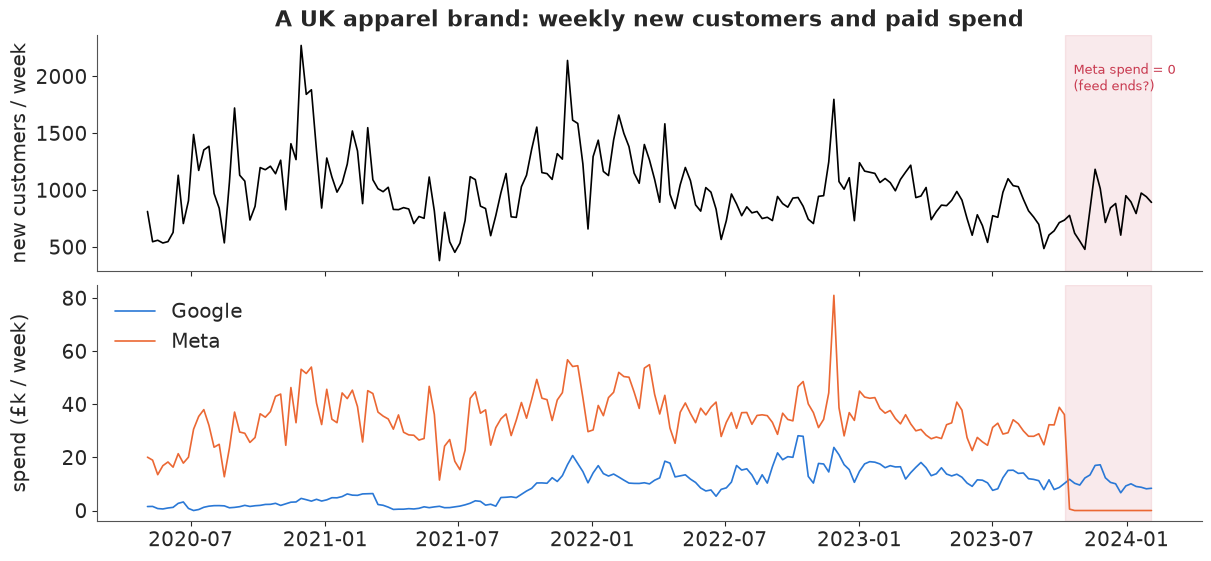

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5.5), sharex=True)
axes[0].plot(weekly_all.index, weekly_all["FIRST_PURCHASES"], color="k", lw=1.2)
axes[0].set_ylabel("new customers / week")
axes[1].plot(weekly_all.index, weekly_all["google"] / 1e3, color=BLUE, lw=1.2, label="Google")
axes[1].plot(weekly_all.index, weekly_all["meta"] / 1e3, color=ORANGE, lw=1.2, label="Meta")
axes[1].set_ylabel("spend (£k / week)")
axes[1].legend()
for ax in axes:
    ax.axvspan(feed_end - pd.Timedelta(days=6), weekly_all.index.max(), color=RED, alpha=0.1)
axes[0].text(feed_end, axes[0].get_ylim()[1] * 0.9, " Meta spend = 0\n (feed ends?)", color=RED,
             va="top", fontsize=9)
axes[0].set_title("A UK apparel brand: weekly new customers and paid spend")
fig.align_ylabels();

One data problem first. Meta spend drops from about £35k a week to £548 in the week ending
15 October 2023 and to **exactly zero** from then to the end, while new customers carry on at their usual level
after the Black Friday peak. E34 and E35 found the same mid-October 2023 Meta cut-off in other brands of
this dataset. A company-wide switch-off is possible, but a **Meta data feed that stopped** is
the likelier story, and a flexible response curve would read those weeks as "zero Meta spend
costs almost nothing", which would bend the curve. We stop the series at the last full week
of Meta data (a "Try it yourself" item keeps the rest in).

In [15]:
weekly = weekly_all[weekly_all.index < feed_end].copy()
CHANNELS = ["google", "meta"]
SPEND = weekly[CHANNELS].to_numpy()
SPEND_MEAN = SPEND.mean(axis=0)
X_SPEND = SPEND / SPEND_MEAN  # 1 = the channel's average week
y_obs = weekly["FIRST_PURCHASES"].to_numpy()
T = len(weekly)
t_years = np.arange(T) / 52.18
FOURIER = np.column_stack([f(2 * np.pi * j * t_years) for j in (1, 2, 3) for f in (np.sin, np.cos)])
TREND = (t_years - t_years.mean()) / t_years.std()
idx = weekly.index
black_friday = ((idx.month == 11) & (idx.day >= 22)) | ((idx.month == 12) & (idx.day <= 3))
christmas = ((idx.month == 12) & (idx.day >= 20)) | ((idx.month == 1) & (idx.day <= 3))
HOLIDAYS = np.column_stack([black_friday, christmas]).astype(float)
print(f"{T} weeks, {idx.min().date()} -> {idx.max().date()}; average spend: "
      + ", ".join(f"{c} £{m:,.0f}" for c, m in zip(CHANNELS, SPEND_MEAN)))
print("spend range in units of an average week (min, 5%, 95%, max):")
for j, ch in enumerate(CHANNELS):
    print(f"  {ch:7s}", np.quantile(X_SPEND[:, j], [0, 0.05, 0.95, 1]).round(2))

180 weeks, 2020-05-03 -> 2023-10-08; average spend: google £9,078, meta £34,991
spend range in units of an average week (min, 5%, 95%, max):
  google  [0.   0.09 2.05 3.1 ]
  meta    [0.33 0.54 1.48 2.32]


### The model

A deliberately conventional MMM, so that the only thing that changes between models is the
response curve. Weekly new customers follow a negative binomial with mean

$$ \mu_t = \underbrace{\exp\big(a_0 + b_{\text{trend}}\,t + \text{Fourier}_t + \text{holidays}_t\big)}_{\text{baseline}}
  + \sum_{\text{channel } j} \beta_j\, f_j\big(\text{adstock}_j(x_{j})_t\big). $$

Media adds customers on top of the baseline. $\beta_j$, the customers a channel brings in an
average week, gets its prior through the **average cost per customer** at average spend,
$\text{CAC}_j = \bar{S}_j / \beta_j \sim \text{LogNormal}(\log 60, 0.8)$: £60 with a wide
spread, the units a marketer would argue about. Three response curves $f$:

- **Weibull**: the family above, $k \sim \text{LogNormal}(0, 0.5)$, $c \sim \text{HalfNormal}(1.5)$;
- **Hill**: $f = \frac{x^n}{K^n + x^n} \cdot (K^n + 1)$, $K \sim \text{LogNormal}(0, 0.7)$,
  $n \sim \text{LogNormal}(0.3, 0.5)$ (concave or S);
- **logistic saturation**: normalised at $x = 1$, $\lambda \sim \text{LogNormal}(0, 1)$ (concave only).

All three normalise $f(1) = 1$, so $\beta$ means the same thing in each.

In [16]:
def build_mmm(y, x_spend, curve="weibull"):
    coords = {"channel": CHANNELS, "week": np.arange(len(y)), "fourier": np.arange(FOURIER.shape[1]),
              "holiday": ["black_friday", "christmas"]}
    x_jax = jnp.asarray(x_spend)
    n_ch = len(CHANNELS)
    with pm.Model(coords=coords) as model:
        theta = pm.Beta("theta", 2.0, 2.0, dims="channel")  # adstock retention per week
        cac = pm.LogNormal("cac", np.log(60.0), 0.8, dims="channel")
        beta = pm.Deterministic("beta", SPEND_MEAN / cac, dims="channel")
        theta_ = pt.specify_shape(theta, (n_ch,))
        if curve == "weibull":
            k = pm.LogNormal("k", 0.0, 0.5, dims="channel")
            c = pm.HalfNormal("c", 1.5, dims="channel")
            transform = pytensor.wrap_jax(lambda th, k_, c_: media_transform(x_jax, th, k_, c_))
            f = transform(theta_, pt.specify_shape(k, (n_ch,)), pt.specify_shape(c, (n_ch,)))
        else:
            adstock = pytensor.wrap_jax(lambda th: geometric_adstock(x_jax, th))(theta_)
            if curve == "hill":
                K = pm.LogNormal("K", 0.0, 0.7, dims="channel")
                n = pm.LogNormal("n", 0.3, 0.5, dims="channel")
                f = adstock**n / (K**n + adstock**n) * (K**n + 1)
            elif curve == "logistic":
                lam = pm.LogNormal("lam", 0.0, 1.0, dims="channel")
                sat = lambda z: (1 - pt.exp(-z)) / (1 + pt.exp(-z))  # noqa: E731
                f = sat(lam * adstock) / sat(lam)
            else:
                raise ValueError(curve)
        a0 = pm.Normal("a0", np.log(np.median(y) / 2), 0.5)
        b_trend = pm.Normal("b_trend", 0.0, 0.3)
        b_fourier = pm.Normal("b_fourier", 0.0, 0.2, dims="fourier")
        b_holiday = pm.Normal("b_holiday", 0.0, 0.5, dims="holiday")
        baseline = pm.Deterministic(
            "baseline", pt.exp(a0 + b_trend * TREND + FOURIER @ b_fourier + HOLIDAYS @ b_holiday),
            dims="week")
        mu = baseline + f @ beta
        alpha = pm.Gamma("alpha", 2.0, 0.05)
        pm.NegativeBinomial("y", mu=mu, alpha=alpha, observed=y, dims="week")
    return model


model_weibull = build_mmm(y_obs, X_SPEND, "weibull")
print(model_weibull.point_logps())

{'theta': np.float64(-1.96), 'cac': np.float64(-1.55), 'k': np.float64(-0.51), 'c': np.float64(-1.45), 'a0': np.float64(-0.23), 'b_trend': np.float64(0.29), 'b_fourier': np.float64(4.14), 'b_holiday': np.float64(-0.45), 'alpha': np.float64(-0.61), 'y': np.float64(-1335.94)}


Before sampling, check the wrapped `Op`'s gradient the PyTensor way: `verify_grad` compares
the symbolic (here: JAX) gradient with finite differences along random directions.

In [17]:
transform_only = pytensor.wrap_jax(lambda th, k_, c_: media_transform(jnp.asarray(X_SPEND), th, k_, c_))
pytensor.gradient.verify_grad(
    lambda th, k_, c_: transform_only(th, k_, c_).sum(),
    [np.array([0.4, 0.2]), np.array([1.7, 0.8]), np.array([0.3, 1e-5])],
    rng=np.random.default_rng(RANDOM_SEED), eps=1e-7)
print("verify_grad passed (one input sits in the series branch, c = 1e-5)")

verify_grad passed (one input sits in the series branch, c = 1e-5)


### Prior predictive: a prior on shapes

With a flexible family, the prior on $(k, c)$ is a prior on **shapes**, so it is worth looking
at in those terms: how often each shape class appears on the data range, and what the curves
look like in customers per week.

prior shape classes on 0 <= x <= 2.5: {'concave': 0.52, '≈ linear': 0.0, 'convex': 0.02, 'S-shaped': 0.46}


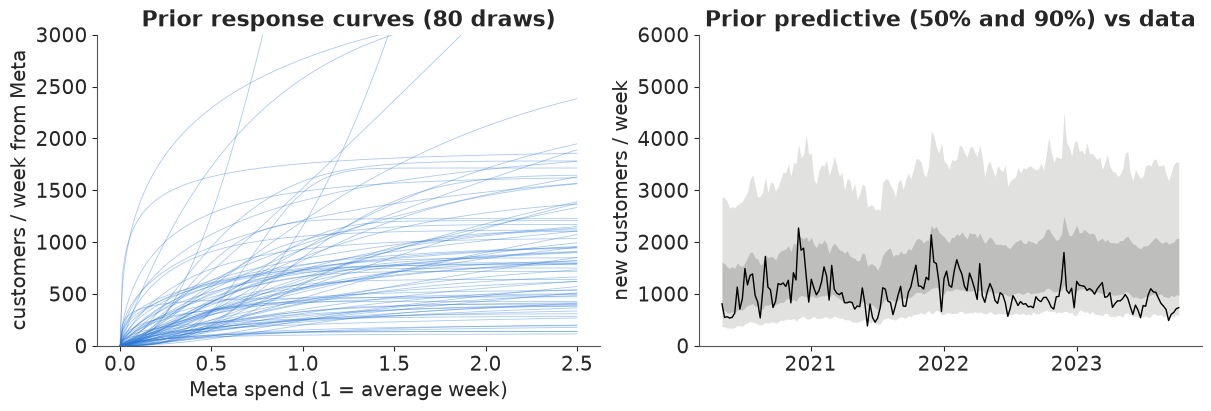

In [18]:
with model_weibull:
    prior = pm.sample_prior_predictive(1000, random_seed=RANDOM_SEED)
pk = prior.prior["k"].values.reshape(-1, 2)
pc = prior.prior["c"].values.reshape(-1, 2)
pb = prior.prior["beta"].values.reshape(-1, 2)
prior_classes = shape_class(pk[:, 0], pc[:, 0])
print("prior shape classes on 0 <= x <= 2.5:",
      {n: round(float(np.mean(prior_classes == i)), 2) for i, n in enumerate(SHAPE_NAMES)})
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
xg = np.linspace(0, X_RANGE, 200)
for i in range(80):
    axes[0].plot(xg, pb[i, 1] * weibull_np(xg, pk[i, 1], pc[i, 1]), color=BLUE, lw=0.6, alpha=0.4)
axes[0].set(xlabel="Meta spend (1 = average week)", ylabel="customers / week from Meta",
            title="Prior response curves (80 draws)", ylim=(0, 3000))
y_prior = prior.prior_predictive["y"].values.reshape(-1, T)
for q_lo, q_hi, a in [(0.05, 0.95, 0.25), (0.25, 0.75, 0.4)]:
    axes[1].fill_between(idx, *np.quantile(y_prior, [q_lo, q_hi], axis=0), color=GREY, alpha=a, lw=0)
axes[1].plot(idx, y_obs, color="k", lw=1)
axes[1].set(ylabel="new customers / week", title="Prior predictive (50% and 90%) vs data", ylim=(0, 6000))
axes[1].xaxis.set_major_locator(plt.matplotlib.dates.YearLocator())
axes[1].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%Y"))

The prior is split roughly evenly between concave and S-shaped curves on the data range;
convex and near-linear curves are rare, because they need $c$ close to zero, where
HalfNormal(1.5) puts little mass. That is a choice worth stating: this prior leans towards
saturation. Response curves range from a few dozen to a few thousand customers a week, and the
prior predictive covers the data without being absurd.

## 7 · Fake data: when the family is too narrow

Before the real data, a check with a known answer. Keep the brand's real spend (so the design
is realistic), and simulate new customers with **Google S-shaped** (a Hill curve, $K = 1.2$,
$n = 3$, 350 customers in an average week) and **Meta as a pure power curve** $300\,x^{0.6}$
(concave, never saturating), adstock retention 0.5 and 0.3, and negative binomial noise close to
what the real data turn out to have. Then fit all three models. The Hill curve is not in the
Weibull family (only approximated, section 4); the power curve is, at $c = 0$, a corner the prior
makes unlikely; and the logistic model cannot make an S at all.

In [19]:
THETA_TRUE = np.array([0.5, 0.3])
ad_true = np.asarray(geometric_adstock(jnp.asarray(X_SPEND), jnp.asarray(THETA_TRUE)))
truth_curves = {"google": lambda x: 350 * hill_np(x, 1.2, 3.0) / hill_np(1.0, 1.2, 3.0),
                "meta": lambda x: 300 * x**0.6}
baseline_true = np.exp(np.log(500) + 0.15 * TREND + FOURIER @ np.array([0.1, -0.05, 0.05, 0, 0, 0.03])
                       + HOLIDAYS @ np.array([0.5, 0.2]))
mu_true = baseline_true + truth_curves["google"](ad_true[:, 0]) + truth_curves["meta"](ad_true[:, 1])
ALPHA_TRUE = 35.0
y_fake = rng.negative_binomial(ALPHA_TRUE, ALPHA_TRUE / (ALPHA_TRUE + mu_true))
print(f"simulated weekly customers: mean {y_fake.mean():.0f}, media share "
      f"{(mu_true - baseline_true).sum() / mu_true.sum():.0%}")


def fit(model, **kw):
    t0 = time.perf_counter()
    idata = pm.sample(model=model, random_seed=RANDOM_SEED, progressbar=False,
                      var_names=[v.name for v in model.free_RVs] + ["beta"], **kw)
    idata.attrs["seconds"] = time.perf_counter() - t0
    n_div = int(idata.sample_stats["diverging"].sum())
    rhat = float(az.summary(idata, var_names=[v.name for v in model.free_RVs])["r_hat"].max())
    print(f"  {idata.attrs['seconds']:.0f} s, {n_div} divergences, max r_hat {rhat:.3f}")
    return idata


fake_fits = {}
for curve in ("weibull", "hill", "logistic"):
    print(curve)
    fake_fits[curve] = fit(build_mmm(y_fake, X_SPEND, curve))

simulated weekly customers: mean 1193, media share 56%
weibull


  12 s, 0 divergences, max r_hat 1.016
hill


  9 s, 0 divergences, max r_hat 1.005
logistic


  7 s, 0 divergences, max r_hat 1.009


To compare the three models' curves we need each posterior's response curve and its slope.
The Weibull ones come straight from the JAX function: `jax.vmap` over posterior draws for the
curve and `jax.vmap(jax.grad(...))` for the slope, with no hand-derived derivative.

customers at x=1  marginal at x=1 (median)  \
channel model                                                  
google  weibull              369.0                     514.0   
        hill                 360.0                     537.0   
        logistic             449.0                     430.0   
        TRUTH                350.0                     665.0   
meta    weibull              489.0                     214.0   
        hill                 488.0                     213.0   
        logistic             386.0                     203.0   
        TRUTH                300.0                     180.0   

                 marginal 90% interval  
channel model                           
google  weibull              401 - 672  
        hill                 416 - 672  
        logistic             352 - 498  
        TRUTH                           
meta    weibull              106 - 350  
        hill                 110 - 333  
        logistic              70 - 340  
        TRUTH

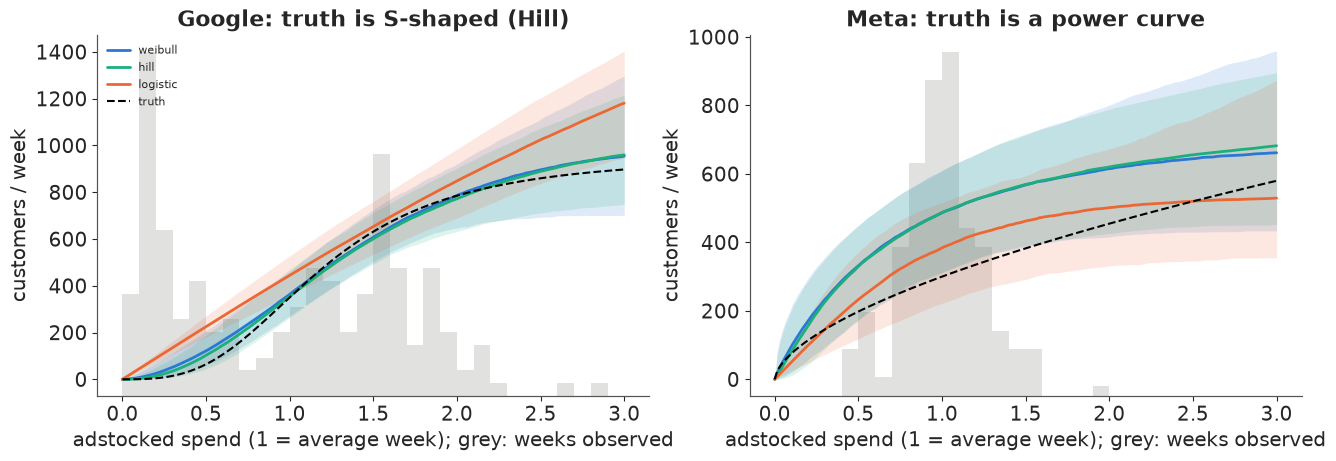

In [20]:
def curve_draws(idata, curve, j, x, n=1000):
    """Posterior response curves (draw, x) in customers/week for channel j, and slope at x = 1."""
    post = az.extract(idata, num_samples=n, random_seed=RANDOM_SEED)
    beta = post["beta"].values[j]
    if curve == "weibull":
        k, c = post["k"].values[j], post["c"].values[j]
        f = jax.vmap(weibull, in_axes=(None, 0, 0))(jnp.asarray(x), k, c)
        slope = jax.vmap(jax.grad(weibull), in_axes=(None, 0, 0))(1.0, k, c)
    elif curve == "hill":
        K, n_ = post["K"].values[j][:, None], post["n"].values[j][:, None]
        hill = lambda z: z**n_ / (K**n_ + z**n_) * (K**n_ + 1)  # noqa: E731
        f, slope = hill(x[None]), ((hill(1.0 + 1e-5) - hill(1.0 - 1e-5)) / 2e-5)[:, 0]
    else:
        lam = post["lam"].values[j][:, None]
        sat = lambda z: (1 - np.exp(-lam * z)) / (1 + np.exp(-lam * z)) / logistic_np(1.0, lam)  # noqa: E731
        f, slope = sat(x[None]), ((sat(1.0 + 1e-5) - sat(1.0 - 1e-5)) / 2e-5)[:, 0]
    return beta[:, None] * np.asarray(f), beta * np.asarray(slope)


CURVE_COLORS = {"weibull": BLUE, "hill": AQUA, "logistic": ORANGE}
xg = np.linspace(0, 3, 200)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
rows = []
for j, (ax, ch) in enumerate(zip(axes, CHANNELS)):
    for curve, idata in fake_fits.items():
        f, slope = curve_draws(idata, curve, j, xg)
        lo, md, hi = np.quantile(f, [0.05, 0.5, 0.95], axis=0)
        ax.fill_between(xg, lo, hi, color=CURVE_COLORS[curve], alpha=0.15, lw=0)
        ax.plot(xg, md, color=CURVE_COLORS[curve], lw=2, label=curve)
        rows.append({"channel": ch, "model": curve, "customers at x=1": np.median(f[:, np.searchsorted(xg, 1.0)]),
                     "marginal at x=1 (median)": np.median(slope),
                     "marginal 90% interval": f"{np.quantile(slope, 0.05):.0f} - {np.quantile(slope, 0.95):.0f}"})
    true_f = truth_curves[ch](xg)
    ax.plot(xg, true_f, "k--", lw=1.5, label="truth")
    rows.append({"channel": ch, "model": "TRUTH", "customers at x=1": truth_curves[ch](1.0),
                 "marginal at x=1 (median)": (truth_curves[ch](1.001) - truth_curves[ch](0.999)) / 0.002,
                 "marginal 90% interval": ""})
    ax2 = ax.twinx()
    ax2.hist(ad_true[:, j], bins=30, range=(0, 3), color=GREY, alpha=0.25)
    ax2.set_yticks([])
    ax.set(xlabel="adstocked spend (1 = average week); grey: weeks observed", ylabel="customers / week",
           title=f"{ch.title()}: truth is {'S-shaped (Hill)' if ch == 'google' else 'a power curve'}")
    ax.set_zorder(ax2.get_zorder() + 1)
    ax.patch.set_visible(False)
axes[0].legend(fontsize=8, loc="upper left")
display(pd.DataFrame(rows).set_index(["channel", "model"]).round(0));

**Reading the fake-data check.** (The marginal effect is in customers per week per extra
"average week" of spend; divide the average spend by it to get the marginal cost per customer.)

- **Google, S-shaped truth.** The Weibull and Hill models both bend the right way, flat at low
  spend and steep through the middle, and follow the truth closely wherever there are weeks of
  data. The logistic model cannot start flat, so it draws a nearly straight line through the
  same weeks. The table shows the consequence: it overstates the customers Google brings in an
  average week (about 450 against a true 350) and understates the marginal return, with a 90%
  interval that **excludes the truth**. A family that is too narrow gives a confident wrong
  answer, not an uncertain one. The flexible models also understate the steepest slope of the
  S a little (the truth sits at the top of their intervals): a sharp S gets smoothed out by
  noise and a prior that prefers gentler curves.
- **Meta, power truth.** All three recover the *slope* where the data are (marginal about 200
  against a true 180), and all three overstate the *level*, by 30-60%. This is not about curve
  families. Meta is always on, between 0.4 and 1.6 of an average week, so no week shows what
  zero Meta spend would look like, and the level of the curve trades off against the baseline.
  **For an always-on channel, the marginal return is measured; the average return (and so the
  "average CAC" or ROI) is an extrapolation to zero spend.** Above the data, the Weibull fit
  bends towards saturation because its prior on $c$ expects some, and with no data there, the
  prior wins: section 4's lesson again, inside a posterior.

In [21]:
real_fits = {}
for curve in ("weibull", "hill", "logistic"):
    print(curve)
    real_models = build_mmm(y_obs, X_SPEND, curve)
    real_fits[curve] = fit(real_models)
    pm.compute_log_likelihood(real_fits[curve], model=real_models, progressbar=False)
display(az.summary(real_fits["weibull"], var_names=["theta", "cac", "beta", "k", "c", "alpha"]))

weibull


  9 s, 0 divergences, max r_hat 1.010


hill


  9 s, 3 divergences, max r_hat 1.011


logistic


  6 s, 0 divergences, max r_hat 1.002


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
theta[google],0.194,0.128,0.04,0.43,5842,2672,1.00,0.0017,0.0028
theta[meta],0.0443,0.029,0.0088,0.097,4434,2193,1.00,0.00039,0.00055
cac[google],80,27,49,130,956,1391,1.00,0.9,1.1
cac[meta],56.2,5.3,49,66,808,1171,1.01,0.19,0.16
beta[google],124,36,71,180,956,1391,1.00,1.2,0.68
beta[meta],628,57,530,720,808,1171,1.01,2,1.3
k[google],2.37,0.91,1.1,3.9,1462,1341,1.00,0.023,0.016
k[meta],1.54,0.26,1.2,2,1160,1747,1.00,0.0075,0.0051
c[google],0.63,0.27,0.27,1.1,1482,1164,1.00,0.0064,0.007
c[meta],0.42,0.232,0.067,0.81,1518,1228,1.00,0.0056,0.0033


In [22]:
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Estimated shape parameter of Pareto")
    cmp = az.compare(real_fits, round_to=1)
    for curve, idata in real_fits.items():
        k_hat = np.asarray(az.loo(idata, pointwise=True).pareto_k)
        worst_week = idx[int(np.argmax(k_hat))].date()
        print(f"{curve:8s}: {int((k_hat > 0.7).sum())} weeks with Pareto k > 0.7 "
              f"(worst {k_hat.max():.2f}, week ending {worst_week})")
display(cmp[["elpd", "p", "elpd_diff", "dse", "weight"]])
for idata in real_fits.values():
    del idata["log_likelihood"]  # LOO is done; the pointwise matrix is not needed any more

weibull : 0 weeks with Pareto k > 0.7 (worst 0.68, week ending 2020-11-22)
hill    : 0 weeks with Pareto k > 0.7 (worst 0.63, week ending 2020-11-29)
logistic: 0 weeks with Pareto k > 0.7 (worst 0.52, week ending 2020-11-22)


,elpd,p,elpd_diff,dse,weight
weibull,-1168.8,14.9,0.0,0.0,1.0
hill,-1169.4,14.5,-0.5,0.5,0.0
logistic,-1173.6,13.0,-4.7,2.3,0.0


The sampler has no trouble with the Weibull model (no divergences, r_hat at most 1.01; the Hill
model has a few divergences). LOO puts the **Weibull and Hill models level** and the **logistic
model behind by about 5 points of elpd, two standard errors of the difference**. That is
moderate, not overwhelming, evidence against the concave-only family, and no week has a Pareto
$\hat{k}$ above 0.7, so the estimates are reliable. Where do the models differ?

average CAC £ (median)  marginal CAC £ (median)  \
channel model                                                       
google  weibull                     75.0                     48.0   
        hill                        74.0                     52.0   
        logistic                    81.0                     91.0   
meta    weibull                     56.0                     46.0   
        hill                        56.0                     46.0   
        logistic                    51.0                     53.0   

                 marginal CAC 90% interval  
channel model                               
google  weibull                  £30 - £91  
        hill                     £32 - £96  
        logistic                £62 - £167  
meta    weibull                  £40 - £53  
        hill                     £40 - £54  
        logistic                 £47 - £60

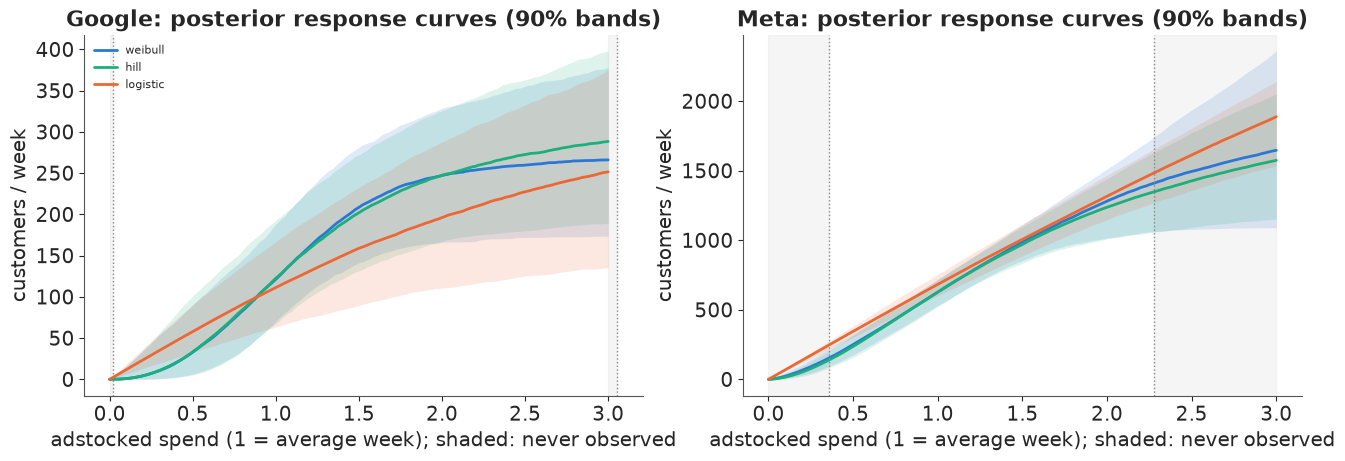

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
real_rows = []
post_w = az.extract(real_fits["weibull"], num_samples=1000, random_seed=RANDOM_SEED)
theta_med = np.median(post_w["theta"].values, axis=1)
ad_med = np.asarray(geometric_adstock(jnp.asarray(X_SPEND), jnp.asarray(theta_med)))
for j, (ax, ch) in enumerate(zip(axes, CHANNELS)):
    for curve, idata in real_fits.items():
        f, slope = curve_draws(idata, curve, j, xg)
        lo, md, hi = np.quantile(f, [0.05, 0.5, 0.95], axis=0)
        ax.fill_between(xg, lo, hi, color=CURVE_COLORS[curve], alpha=0.15, lw=0)
        ax.plot(xg, md, color=CURVE_COLORS[curve], lw=2, label=curve)
        beta = az.extract(idata, var_names="beta", num_samples=1000, random_seed=RANDOM_SEED).values[j]
        real_rows.append({"channel": ch, "model": curve,
                          "average CAC £ (median)": np.median(SPEND_MEAN[j] / beta),
                          "marginal CAC £ (median)": np.median(SPEND_MEAN[j] / slope),
                          "marginal CAC 90% interval": "£{:.0f} - £{:.0f}".format(
                              *np.quantile(SPEND_MEAN[j] / slope, [0.05, 0.95]))})
    lo_obs, hi_obs = np.quantile(ad_med[:, j], [0.0, 1.0])
    for edge in (lo_obs, hi_obs):
        ax.axvline(edge, color=GREY, ls=":", lw=1)
    ax.axvspan(0, lo_obs, color=GREY, alpha=0.08)
    ax.axvspan(hi_obs, 3, color=GREY, alpha=0.08)
    ax.set(xlabel="adstocked spend (1 = average week); shaded: never observed",
           ylabel="customers / week", title=f"{ch.title()}: posterior response curves (90% bands)")
axes[0].legend(fontsize=8, loc="upper left")
display(pd.DataFrame(real_rows).set_index(["channel", "model"]).round(0));

The two flexible models agree with each other almost exactly, and they differ from the logistic
model where it matters for a decision.

- **Google** is S-shaped in the flexible models: little response below about half an average
  week, then a steep rise, then flattening above twice the average. The logistic model draws a
  concave curve through the same weeks. At current spend the flexible models put Google's
  **marginal** cost per customer at about £50, the logistic model at about £90, with 90%
  intervals that overlap only between about £60 and £90. The two families would give opposite advice on moving budget into Google.
- **Meta**'s curves are nearly identical in all three models over the observed range (0.36 to 2.3
  of an average week) and nearly straight; the flexible models' marginal CAC (£46) is a little
  below their average CAC (£56).

One more sensitivity worth knowing about: the week ending 15 October 2023, with £549 of Meta
spend, is *not* in the data. With it included (an earlier draft of this notebook did that), a
single week at 2% of normal Meta spend moved Meta's average CAC from £56 to about £85 and the
shape parameters with it. Curves are learned from the extremes of spend, so the extremes deserve
the most scrutiny.

Where do the posteriors sit on the shape map, and which shape class do they give each channel?

,concave,≈ linear,convex,S-shaped,inflection inside observed range,median inflection x*,observed range
google,0.036,0.003,0.003,0.958,0.96,0.935824,0.02 - 3.06
meta,0.004,0.036,0.057,0.903,0.924,0.887844,0.36 - 2.27


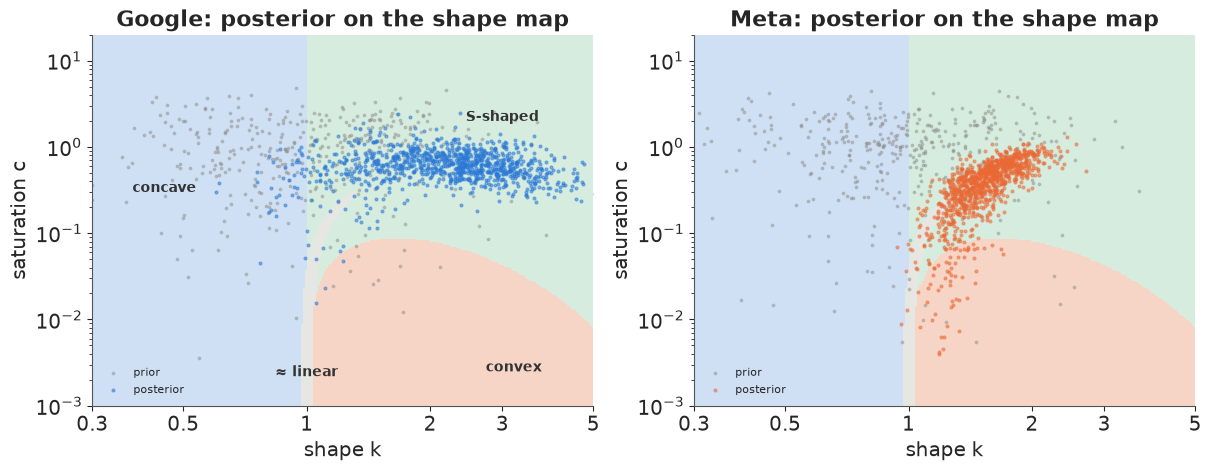

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
shape_rows = {}
for j, (ax, ch) in enumerate(zip(axes, CHANNELS)):
    draw_shape_map(ax, labels=(j == 0))
    k_d, c_d = post_w["k"].values[j], post_w["c"].values[j]
    ax.scatter(pk[:400, j], pc[:400, j], s=3, color=GREY, alpha=0.4, label="prior")
    ax.scatter(k_d, c_d, s=4, color=BLUE if j == 0 else ORANGE, alpha=0.5, label="posterior")
    ax.set(xlim=(kg[0], kg[-1]), ylim=(cg[0], cg[-1]), title=f"{ch.title()}: posterior on the shape map")
    ax.legend(fontsize=8, loc="lower left")
    x_obs_max = ad_med[:, j].max()
    x_star = inflection(k_d, c_d)
    shape_rows[ch] = {**{n: float(np.mean(shape_class(k_d, c_d) == i)) for i, n in enumerate(SHAPE_NAMES)},
                      "inflection inside observed range": float(np.mean(
                          (x_star > ad_med[:, j].min()) & (x_star < x_obs_max))),
                      "median inflection x*": float(np.median(x_star[np.isfinite(x_star)])),
                      "observed range": f"{ad_med[:, j].min():.2f} - {x_obs_max:.2f}"}
display(pd.DataFrame(shape_rows).T.round(2));

- **Both channels move to the S-shaped region**, from a prior that gave S-curves about 46%:
  the posterior probability of an S with its inflection inside the observed range is above 0.9
  for both, with the inflection near an average week.
- **Meta**'s cloud is tight and runs down into the convex region: with its lowest weeks at 0.36
  of average spend, the data cannot distinguish "an S whose lower bend is below 0.36" from
  "convex"; the posterior hedges between them.
- **Google**'s shape is less certain ($k$ between about 1 and 4), but it is S-shaped in almost
  every draw.

### Should we believe S-shaped curves?

An S-curve says there is a threshold: spend below it is mostly wasted. Before a CFO hears that,
two alternative explanations should be ruled out:

1. **Time, not spend.** Google spend was tiny in 2020-21 and grew over the following years (see
   the data plot). The flat start of its S is learned from those early weeks, when many other
   things were different. A linear trend and a yearly season in the baseline cannot absorb all
   of that, and the S may partly be a story about 2020.
2. **Spend chases demand.** When a budget algorithm or a planner raises spend in weeks that
   were going to sell well anyway, high-spend weeks have high sales for other reasons, and the
   curve steepens at the top. That is the endogeneity E32 built a likelihood for. A concave
   family **hides** such a distortion (it cannot bend upwards, so the distortion leaks into
   other parameters); a flexible family **exposes** it. Flexibility does not fix confounding,
   it makes it visible.

The flexible model is the right tool for asking the question, not the last word on the answer.
A holdout or geo experiment (E34) is what settles it.

A posterior predictive check to finish: do the fitted models reproduce the weekly series?

NB alpha = 42: at 1,000 customers/week the sd is 157 (16%)


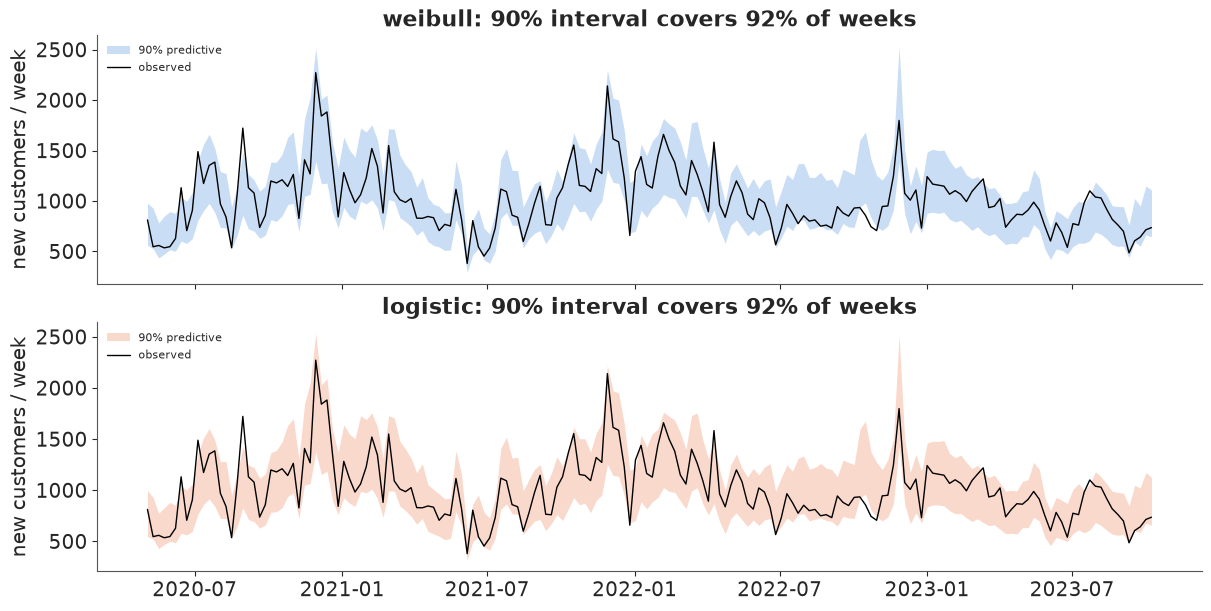

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for ax, curve in zip(axes, ("weibull", "logistic")):
    model = build_mmm(y_obs, X_SPEND, curve)
    with model:
        ppc = pm.sample_posterior_predictive(real_fits[curve], random_seed=RANDOM_SEED, progressbar=False)
    y_rep = ppc.posterior_predictive["y"].values.reshape(-1, T)
    lo, hi = np.quantile(y_rep, [0.05, 0.95], axis=0)
    ax.fill_between(idx, lo, hi, color=CURVE_COLORS[curve], alpha=0.25, lw=0, label="90% predictive")
    ax.plot(idx, y_obs, color="k", lw=1, label="observed")
    coverage = np.mean((y_obs >= lo) & (y_obs <= hi))
    ax.set(ylabel="new customers / week", title=f"{curve}: 90% interval covers {coverage:.0%} of weeks")
    ax.legend(fontsize=8, loc="upper left")
    del ppc, y_rep
alpha_med = float(real_fits["weibull"].posterior["alpha"].median())
print(f"NB alpha = {alpha_med:.0f}: at 1,000 customers/week the sd is "
      f"{np.sqrt(1000 + 1000**2 / alpha_med):.0f} ({np.sqrt(1000 + 1000**2 / alpha_med) / 10:.0f}%)")

Both models track the series, with 90% intervals covering 93% of weeks, so a time-series PPC
cannot tell them apart. The difference LOO found is spread thinly over many weeks: it concerns
the *shape* of the curves, which barely moves the total. That is typical. In MMMs, the part of
the model a decision depends on is often the part a fit plot says least about.

## 9 · Performance: a JAX node inside a Numba graph, or all JAX?

By default nutpie compiles the model with Numba and calls the wrapped JAX function as a single
node, in Numba's "object mode" (a Python call, hence the warning we silenced at the top), with a
separate call for its gradient. The whole model can also be compiled to JAX, in which case
`wrap_jax`'s node is inlined into one XLA program (E09 explains why this works for `wrap_jax` and
not for a hand-written `Op`). Time one log-density + gradient evaluation each way, then sample
with the JAX backend.

In [26]:
def time_logp_grad(model, mode, reps=300):
    logp = model.logp()
    fn = pytensor.function(model.value_vars, [logp, *pt.grad(logp, model.value_vars)], mode=mode)
    point = model.initial_point()
    args = [point[v.name] for v in model.value_vars]
    fn(*args)  # compile / warm up
    t0 = time.perf_counter()
    for _ in range(reps):
        fn(*args)
    return 1e6 * (time.perf_counter() - t0) / reps


timings = {"Numba graph + JAX node": time_logp_grad(model_weibull, "NUMBA"),
           "whole model in JAX": time_logp_grad(model_weibull, "JAX")}
for name, us in timings.items():
    print(f"{name:24s} {us:7.0f} µs per logp + gradient")
print("sampling, Numba backend (section 8):", f"{real_fits['weibull'].attrs['seconds']:.0f} s")
idata_jax = fit(model_weibull, backend="jax", compile_kwargs={"gradient_backend": "jax"})
jax_vs_numba = float(np.abs(idata_jax.posterior["k"].median(["chain", "draw"])
                            - real_fits["weibull"].posterior["k"].median(["chain", "draw"])).max())
print(f"largest difference in posterior median k between backends: {jax_vs_numba:.2f}")
del idata_jax
jax.clear_caches()

Numba graph + JAX node       115 µs per logp + gradient
whole model in JAX            35 µs per logp + gradient
sampling, Numba backend (section 8): 9 s


  5 s, 0 divergences, max r_hat 1.003
largest difference in posterior median k between backends: 0.02


Compiling the whole model to JAX makes one log-density + gradient about three times faster
(the object-mode call into JAX costs more than the arithmetic), and sampling takes about half
the time; the two backends give the same posterior. With 180 weeks and two channels both are
fast. The whole-model JAX route pays off more with larger models (many geos, E33) or on a GPU,
where float32 is the norm, which is one more reason section 3 made the function float32-safe.

## Summary

- **The response family is a prior**, and a strong one: it decides which shapes have any
  probability at all. Hill, logistic and power curves agree at the reference spend and
  disagree by a factor of four on the marginal return (section 1).
- **One family, three behaviours.** $f(x) = (1 - e^{-cx^k})/(1 - e^{-c})$ contains power
  curves ($c = 0$), concave saturation ($k \le 1$) and S-curves ($k > 1$, inflection at
  $((k-1)/(ck))^{1/k}$), and moves between them smoothly, which NUTS needs (section 2).
- **A custom JAX function needs the same care as any numerical code**: `expm1` plus a series
  switch for $c \to 0$, the double-`where` trick for zero spend, float32 in mind, and unit tests
  for limits, gradients and curvature (section 3).
- **It imitates the standard curves to about 1%** over the data range, far below weekly noise.
  Batched fits with `vmap` check that in a few seconds and translate a Hill prior into
  $(k, c)$. Outside the data, families diverge, and so do their decisions (sections 4-5).
- **In a Bayesian MMM** the flexible family recovers an S-shaped truth where a concave-only
  model gives a confident wrong marginal return. For an always-on channel only the marginal
  return is measured; the level is an extrapolation (section 7).
- **On a real brand**, the flexible models find S-curves for both channels and roughly halve
  Google's marginal cost per customer relative to the logistic model, which LOO ranks lower.
  Whether the S is real or reflects time trends and demand-chasing spend is a question for an
  experiment (section 8).

## Try it yourself

1. **Keep the "feed ends" weeks.** Refit on `weekly_all` (Meta spend near zero or zero for the
   last 17 weeks). How do Meta's average and marginal CAC and its position on the shape map change?
   Is the result a better or a worse description of the brand if the zeros are a lost feed?
2. **Use the translated Hill prior.** Replace the independent priors on $k$ and $c$ by the
   bivariate normal on $(\log k, \log c)$ from section 5 (`pm.MvNormal` on a length-2 vector
   per channel, exponentiated). Which conclusions in section 8 depend on the shape prior?
3. **Weibull adstock.** Robyn's other use of the Weibull family is for the **adstock**: lag
   weights $w_\ell \propto$ Weibull PDF or survival function at lag $\ell$, so the peak effect
   can come weeks after the spend. Write it as a JAX convolution (`jnp.convolve` or a
   `lax.scan` over a lag window), put it in `media_transform`, and compare with geometric
   adstock by LOO.